# Forecast Dashboard

Notebook corto y centrado solo en carga futura.

Aqui no se rehace la limpieza del dataset. Todo se consume desde `src.pipeline`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline import run_baseline_pipeline

PATH_XLSX = project_root / "data" / "raw" / "DatosBusquedaAvanzada20250208.xlsx"

artifacts = run_baseline_pipeline(
    workbook_path=PATH_XLSX,
    rate_window_days=60,
    dashboard_horizon_days=5,
    scenario_horizons=(5, 10, 20),
)

forecast_dashboard = artifacts["forecast_dashboard"]
forecast_dashboard_export = artifacts["forecast_dashboard_export"]
forecast_scenarios = artifacts["forecast_scenarios"]


In [2]:
display(forecast_dashboard_export)
display(forecast_scenarios)


,Owner,arrival_rate_per_day,completion_rate_per_day,current_wip,expected_arrivals,expected_completions,forecast_wip,status,status_reason
0,Consultor 2,0.02,0.00,3,0.08,0.00,3.08,no_throughput,open work but no recent completions
1,Comercial 2,0.00,0.00,1,0.00,0.00,1.0,no_throughput,open work but no recent completions
2,Consultor 1,0.03,0.08,8,0.17,0.42,7.75,risk,projected backlog exceeds horizon
3,Consultor 4,0.00,0.13,6,0.00,0.67,5.33,risk,projected backlog exceeds horizon
4,Técnico 8,0.05,0.12,5,0.25,0.58,4.67,risk,projected backlog exceeds horizon
5,Técnico 4,0.03,0.17,5,0.17,0.83,4.33,risk,projected backlog exceeds horizon
6,Otros 2,0.02,0.03,4,0.08,0.17,3.92,risk,projected backlog exceeds horizon
7,Técnico 7,0.05,0.10,4,0.25,0.50,3.75,risk,projected backlog exceeds horizon
8,Técnico 10,0.00,0.02,2,0.00,0.08,1.92,risk,projected backlog exceeds horizon
9,Consultor 6,0.00,0.05,2,0.00,0.25,1.75,risk,projected backlog exceeds horizon


,Owner,forecast_wip_5d,status_5d,forecast_wip_10d,status_10d,forecast_wip_20d,status_20d
0,Consultor 2,3.08,no_throughput,3.17,no_throughput,3.33,no_throughput
1,Comercial 2,1.0,no_throughput,1.0,no_throughput,1.0,no_throughput
2,Consultor 1,7.75,risk,7.5,risk,7.0,risk
3,Consultor 4,5.33,risk,4.67,risk,3.33,risk
4,Técnico 8,4.67,risk,4.33,risk,3.67,risk
5,Técnico 4,4.33,risk,3.67,risk,2.33,healthy
6,Otros 2,3.92,risk,3.83,risk,3.67,risk
7,Técnico 7,3.75,risk,3.5,risk,3.0,risk
8,Técnico 10,1.92,risk,1.83,risk,1.67,risk
9,Consultor 6,1.75,risk,1.5,risk,1.0,healthy


In [3]:
status_counts = forecast_dashboard["status"].value_counts().rename_axis("status").reset_index(name="owners")
status_counts


,status,owners
0,risk,11
1,healthy,7
2,no_throughput,2


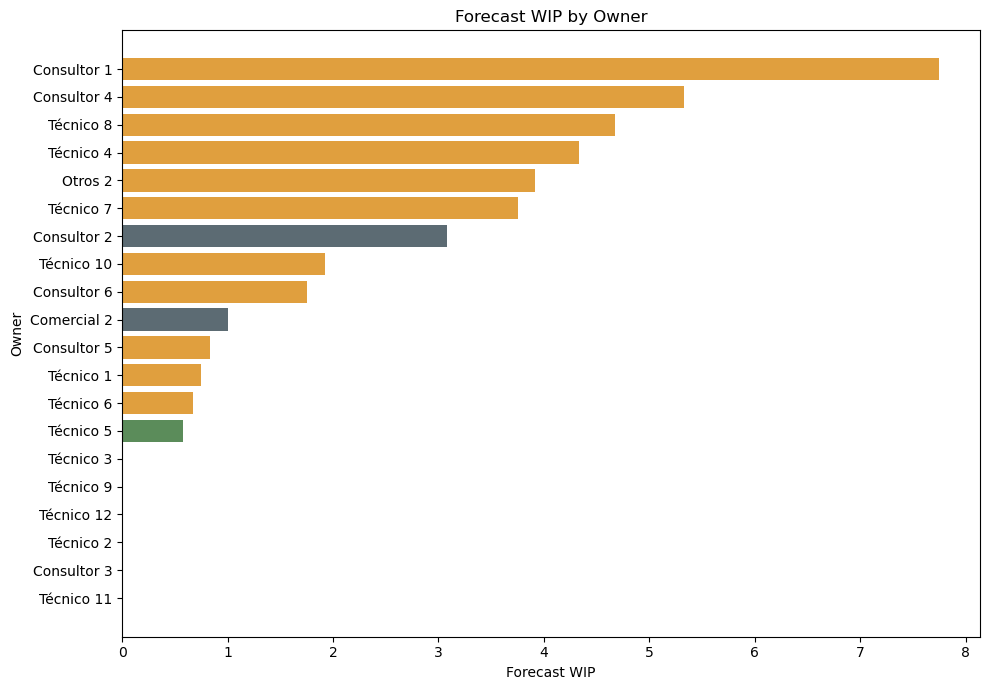

In [4]:
plot_df = forecast_dashboard.sort_values("forecast_wip", ascending=True).copy()
color_map = {
    "healthy": "#5B8C5A",
    "risk": "#E09F3E",
    "overload": "#C8553D",
    "no_throughput": "#5C6B73",
}

plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["Owner"],
    plot_df["forecast_wip"],
    color=plot_df["status"].map(color_map),
)
plt.title("Forecast WIP by Owner")
plt.xlabel("Forecast WIP")
plt.ylabel("Owner")
plt.tight_layout()
plt.show()


In [5]:
scenario_status = (
    forecast_scenarios[["Owner", "status_5d", "status_10d", "status_20d"]]
    .melt(id_vars="Owner", var_name="horizon", value_name="status")
    .groupby(["horizon", "status"])
    .size()
    .rename("owners")
    .reset_index()
)

scenario_status


,horizon,status,owners
0,status_10d,healthy,10
1,status_10d,no_throughput,2
2,status_10d,risk,8
3,status_20d,healthy,12
4,status_20d,no_throughput,2
5,status_20d,risk,6
6,status_5d,healthy,7
7,status_5d,no_throughput,2
8,status_5d,risk,11
